In [64]:
from pathlib import Path
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge

import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import yfinance as yf
import requests
from arch import arch_model
from scipy.stats import spearmanr

In [65]:
def qlike(y_true, y_pred):
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1)


def eval_metrics(y_true, y_pred, label):
    print(f"\n── {label} ──")
    print(
        f"  QLIKE    : {qlike(y_true, y_pred):.6f}  (baseline média: {qlike(y_true, np.full_like(y_true, y_true.mean())):.6f})"
    )
    print(f"  R²       : {r2_score(y_true, y_pred):.4f}")
    print(f"  Spearman : {spearmanr(y_true, y_pred).statistic:.4f}")
    print(f"  std ratio: {y_pred.std() / y_true.std():.3f}  (ideal=1.0)")

In [66]:
START = "2008-01-01"
END = "2025-04-14"
TEST_RATIO = 0.1
SEED = 42
WINDOW_SIZE = 60
VOL_WINDOW = 10  # era 21
VOL_SHIFT = -5  # era -21

FRED_API_KEY = "a75bdc9f7da239a5e3d6c8e389345bfb"
DATA_BASE_PATH = Path("../../data/processed")

In [67]:
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

In [68]:
def get_fred_series(series_id: str, start: str, end: str, api_key: str) -> pd.DataFrame:
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json",
        "observation_start": start,
        "observation_end": end,
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()["observations"]
    df = pd.DataFrame(data)[["date", "value"]]
    df.columns = ["timestamp", series_id.lower()]
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df[series_id.lower()] = pd.to_numeric(df[series_id.lower()], errors="coerce")
    return df.reset_index(drop=True)


dfii10 = get_fred_series("DFII10", START, END, FRED_API_KEY)
dfii10 = dfii10.rename(columns={"dfii10": "inflation"})
print(dfii10.shape)
print(dfii10.head())

(4510, 2)
   timestamp  inflation
0 2008-01-01        NaN
1 2008-01-02       1.59
2 2008-01-03       1.58
3 2008-01-04       1.56
4 2008-01-07       1.57


In [69]:
petrodolar = pd.read_csv(
    DATA_BASE_PATH / "petrodollar_5_daily_prices_fx.csv", parse_dates=["date"]
)
petrodolar = petrodolar.rename(columns={"date": "timestamp"})
petrodolar = petrodolar[
    [
        "timestamp",
        "eur_usd",
    ]
]
petrodolar = petrodolar[
    (petrodolar["timestamp"] >= START) & (petrodolar["timestamp"] <= END)
].reset_index(drop=True)

print(petrodolar.shape)
print(petrodolar.head())


# In[ ]:


opec = pd.read_csv(
    DATA_BASE_PATH / "petrodollar_2_opec_quotas_events.csv", parse_dates=["date"]
)
opec = opec.rename(columns={"date": "timestamp"})
opec["timestamp"] = pd.to_datetime(opec["timestamp"])
opec = opec[
    [
        "timestamp",
        "oil_market_balance_mbd",
    ]
].copy()

print("OPEC:", opec.shape)

(4510, 2)
   timestamp  eur_usd
0 2008-01-01   1.2725
1 2008-01-02   1.2891
2 2008-01-03   1.2693
3 2008-01-04   1.2834
4 2008-01-07   1.2971
OPEC: (312, 2)


In [70]:
tickers = {
    "vix": "^VIX",
    "tnx": "^TNX",
    "gvz": "^GVZ",
}

dfs = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
    close = df["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close.name = name
    dfs[name] = close

externos = pd.concat(dfs.values(), axis=1)
externos.index.name = "timestamp"
externos = externos.reset_index()

print(externos.shape)
print(externos.head())

(4348, 4)
   timestamp        vix    tnx  gvz
0 2008-01-02  23.170000  3.901  NaN
1 2008-01-03  22.490000  3.901  NaN
2 2008-01-04  23.940001  3.854  NaN
3 2008-01-07  23.790001  3.839  NaN
4 2008-01-08  25.430000  3.840  NaN


In [71]:
gold = pd.read_csv(
    DATA_BASE_PATH / "final_gold_data.csv",
    sep=";",
    encoding="utf-8",
    parse_dates=["timestamp"],
)
silver = pd.read_csv(
    DATA_BASE_PATH / "final_silver_data.csv",
    sep=";",
    encoding="utf-8",
    parse_dates=["timestamp"],
)

cols_to_drop = ["currency", "unit", "headlines"]
silver.drop(columns=[c for c in cols_to_drop if c in silver.columns], inplace=True)
silver.rename(
    columns={
        "open": "silver_open",
        "high": "silver_high",
        "low": "silver_low",
        "close": "silver_close",
        "volume": "silver_volume",
    },
    inplace=True,
)

print("Gold:", gold.shape)

Gold: (6177, 9)


In [72]:
for df in [gold, silver, externos]:
    df["timestamp"] = pd.to_datetime(df["timestamp"])

gold = gold.merge(silver[["timestamp", "silver_high"]], on="timestamp", how="left")
gold = gold.merge(externos, on="timestamp", how="left")
gold = gold.merge(dfii10, on="timestamp", how="left")
gold = gold.merge(petrodolar, on="timestamp", how="left")

# Merge mensal: OPEC (merge por ano+mês)
gold["year"] = gold["timestamp"].dt.year
gold["month_"] = gold["timestamp"].dt.month

opec["year"] = opec["timestamp"].dt.year
opec["month_"] = opec["timestamp"].dt.month
opec = opec.drop(columns=["timestamp"])

gold = gold.merge(opec, on=["year", "month_"], how="left")
gold = gold.drop(columns=["year", "month_"])

fill_cols = [
    "vix",
    "tnx",
    "gvz",
    "silver_high",
    "inflation",
    "eur_usd",
    "oil_market_balance_mbd",
]

gold[fill_cols] = gold[fill_cols].ffill().bfill()
gold = gold.dropna()

print("Shape após merge:", gold.shape)
print(gold.isna().sum()[gold.isna().sum() > 0])

Shape após merge: (6177, 16)
Series([], dtype: int64)


In [73]:
gold["tomorrow_close"] = gold["close"].shift(-1)
gold = gold.dropna(subset=["tomorrow_close"])

gold["log_return"] = np.log(gold["close"] / gold["close"].shift(1))

gold["hist_vol_10"] = gold["log_return"].rolling(10).std()

log_ret = gold["log_return"].dropna() * 100
garch_full = arch_model(log_ret, vol="Garch", p=1, q=1)
res_full = garch_full.fit(disp="off")

gold_aligned = gold[gold["log_return"].notna()].copy()
gold_aligned["garch_vol"] = res_full.conditional_volatility.values / 100

gold = gold.merge(gold_aligned[["timestamp", "garch_vol"]], on="timestamp", how="left")
gold["garch_rank"] = gold["garch_vol"].rolling(252).rank(pct=True)

gold["gvz_zscore_60d"] = (gold["gvz"] - gold["gvz"].rolling(60).mean()) / gold[
    "gvz"
].rolling(60).std()

gold["gvz_pct_change"] = gold["gvz"].pct_change(5)

gold["real_rate_proxy"] = gold["tnx"] - gold["inflation"]

delta = gold["close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
gold["rsi_14"] = 100 - (100 / (1 + rs))

gold["target_vol_5d"] = gold["log_return"].rolling(VOL_WINDOW).std().shift(VOL_SHIFT)

In [74]:
gold = gold.dropna()
print("Shape após feature engineering:", gold.shape)
print("NaN restantes:", gold.isna().sum().sum())

Shape após feature engineering: (4235, 26)
NaN restantes: 0


In [75]:
TARGET = "target_vol_5d"

FEATURES_SELECIONADAS = [
    "vix",
    "hist_vol_10",
    "garch_rank",
    "gvz_zscore_60d",
    "gvz_pct_change",
    "oil_market_balance_mbd",
    "eur_usd",
    "silver_high",
    "real_rate_proxy",
    "rsi_14",
]

X = gold[FEATURES_SELECIONADAS].copy()
y = gold[TARGET]

n_features = X.shape[1]
print("Features restantes:", list(X.columns))
print("n_features:", n_features)

Features restantes: ['vix', 'hist_vol_10', 'garch_rank', 'gvz_zscore_60d', 'gvz_pct_change', 'oil_market_balance_mbd', 'eur_usd', 'silver_high', 'real_rate_proxy', 'rsi_14']
n_features: 10


In [76]:
split_idx = int(len(gold) * (1 - TEST_RATIO))

vix_train = gold["vix"].iloc[:split_idx].values
vix_test = gold["vix"].iloc[split_idx:].values
y_train_bl = y.iloc[:split_idx].values
y_test_bl = y.iloc[split_idx:].values

# Regressão linear simples VIX -> target_vol
ridge_bl = Ridge(alpha=1.0)
ridge_bl.fit(vix_train.reshape(-1, 1), y_train_bl)
vix_pred_test = ridge_bl.predict(vix_test.reshape(-1, 1))

r2_vix = r2_score(y_test_bl, vix_pred_test)
mae_vix = mean_absolute_error(y_test_bl, vix_pred_test)
print("\n── Baseline VIX -> vol ──")
print(f"  R²  (teste): {r2_vix:.4f}")
print(f"  MAE (teste): {mae_vix:.6f}")
print(f"  Correlação : {np.corrcoef(y_test_bl, vix_pred_test)[0, 1]:.4f}")
print("  (O GRU precisa superar esse baseline para justificar sua complexidade)")


── Baseline VIX -> vol ──
  R²  (teste): -0.1325
  MAE (teste): 0.002433
  Correlação : 0.0511
  (O GRU precisa superar esse baseline para justificar sua complexidade)


In [77]:
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i : i + window_size])
        ys.append(y.iloc[i + window_size])
    return np.array(Xs), np.array(ys)


X_seq, y_seq = create_sequences(X.to_numpy(), y, WINDOW_SIZE)

mask = ~np.isnan(y_seq)
X_seq = X_seq[mask]
y_seq = y_seq[mask]

print("NaN em y_seq após mask:", np.isnan(y_seq).sum())

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_seq, y_seq, test_size=TEST_RATIO, shuffle=False
)

print("Train:", X_train_full.shape, "Test:", X_test.shape)

NaN em y_seq após mask: 0
Train: (3757, 60, 10) Test: (418, 60, 10)


In [78]:
def build_model(learning_rate=0.001):
    model = Sequential(
        [
            Input(shape=(WINDOW_SIZE, n_features)),
            GRU(128),
            Dropout(0.2),
            Dense(32, activation="relu"),
            Dropout(0.1),
            Dense(1),
        ]
    )
    model.compile(optimizer=Adam(learning_rate), loss="mse")
    return model

In [79]:
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train_full.reshape(-1, n_features)).reshape(
    X_train_full.shape
)
X_test_scaled = x_scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train_full.reshape(-1, 1)).ravel()

print("X_train_scaled:", X_train_scaled.shape)
print("y_train_scaled mean:", y_train_scaled.mean(), "std:", y_train_scaled.std())

X_train_scaled: (3757, 60, 10)
y_train_scaled mean: 1.5130002358479641e-16 std: 1.0


In [80]:
tscv = TimeSeriesSplit(n_splits=5)
folds = list(tscv.split(X_seq))

walk_r2s = []
last_val_idx = None

for fold, (train_idx, val_idx) in enumerate(folds):
    X_tr = X_seq[train_idx]
    X_va = X_seq[val_idx]
    y_tr = y_seq[train_idx]
    y_va = y_seq[val_idx]

    sc_x = StandardScaler()
    X_tr_s = sc_x.fit_transform(X_tr.reshape(-1, n_features)).reshape(X_tr.shape)
    X_va_s = sc_x.transform(X_va.reshape(-1, n_features)).reshape(X_va.shape)

    sc_y = StandardScaler()
    y_tr_s = sc_y.fit_transform(y_tr.reshape(-1, 1)).ravel()
    y_va_s = sc_y.transform(y_va.reshape(-1, 1)).ravel()

    tf.keras.backend.clear_session()
    m = build_model()
    m.fit(
        X_tr_s,
        y_tr_s,
        epochs=100,
        batch_size=32,
        validation_data=(X_va_s, y_va_s),
        shuffle=False,
        verbose=0,
        callbacks=[
            EarlyStopping(patience=10, restore_best_weights=True, min_delta=1e-5)
        ],
    )

    pred_s = m.predict(X_va_s, verbose=0)
    pred = sc_y.inverse_transform(pred_s.reshape(-1, 1)).ravel()
    r2 = r2_score(y_va, pred)
    walk_r2s.append(r2)
    print(
        f"Fold {fold + 1} R²: {r2:.4f}  |  pred_std: {pred.std():.6f}  |  real_std: {y_va.std():.6f}"
    )

    if fold == len(folds) - 1:
        last_val_idx = val_idx

print(f"\nR² médio walk-forward: {np.mean(walk_r2s):.4f}")

val_X_final = x_scaler.transform(X_seq[last_val_idx].reshape(-1, n_features)).reshape(
    X_seq[last_val_idx].shape
)

val_y_final = y_scaler.transform(y_seq[last_val_idx].reshape(-1, 1)).ravel()

Fold 1 R²: 0.4061  |  pred_std: 0.003077  |  real_std: 0.005561
Fold 2 R²: -0.5236  |  pred_std: 0.002561  |  real_std: 0.002938
Fold 3 R²: 0.0808  |  pred_std: 0.001486  |  real_std: 0.001937
Fold 4 R²: 0.5408  |  pred_std: 0.003513  |  real_std: 0.004854
Fold 5 R²: 0.0877  |  pred_std: 0.001164  |  real_std: 0.002722

R² médio walk-forward: 0.1184


In [81]:
TRAIN_YEARS = 4

seq_ts = gold["timestamp"].iloc[WINDOW_SIZE:].reset_index(drop=True)
seq_ts = seq_ts.iloc[mask].reset_index(drop=True)

test_start = seq_ts.iloc[int(len(seq_ts) * (1 - TEST_RATIO))]
train_end = test_start
train_start = train_end - pd.DateOffset(years=TRAIN_YEARS)

slide_mask = (seq_ts >= train_start) & (seq_ts < train_end)
slide_mask = slide_mask.values

X_slide = X_seq[slide_mask]
y_slide = y_seq[slide_mask]

print(f"Janela de treino: {train_start.date()} → {train_end.date()}")
print(f"Amostras: {X_slide.shape}")

x_scaler_slide = StandardScaler()
X_slide_s = x_scaler_slide.fit_transform(X_slide.reshape(-1, n_features)).reshape(
    X_slide.shape
)

y_scaler_slide = StandardScaler()
y_slide_s = y_scaler_slide.fit_transform(y_slide.reshape(-1, 1)).ravel()

X_test_slide_s = x_scaler_slide.transform(X_test.reshape(-1, n_features)).reshape(
    X_test.shape
)

val_cut = int(len(X_slide_s) * 0.85)
val_X_slide = X_slide_s[val_cut:]
val_y_slide = y_slide_s[val_cut:]
X_slide_train = X_slide_s[:val_cut]
y_slide_train = y_slide_s[:val_cut]

print(f"Treino: {X_slide_train.shape}  Val: {val_X_slide.shape}")

tf.keras.backend.clear_session()
final_model = build_model()

history = final_model.fit(
    X_slide_train,
    y_slide_train,
    validation_data=(val_X_slide, val_y_slide),
    epochs=500,
    batch_size=32,
    shuffle=False,
    callbacks=[
        EarlyStopping(
            monitor="val_loss", patience=20, restore_best_weights=True, min_delta=1e-6
        ),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=15, min_lr=1e-6, verbose=1
        ),
    ],
    verbose=1,
)

y_pred_slide_train = y_scaler_slide.inverse_transform(
    final_model.predict(X_slide_train, verbose=0)
).flatten()

y_pred_slide_test = y_scaler_slide.inverse_transform(
    final_model.predict(X_test_slide_s, verbose=0)
).flatten()

y_test_eval = y_test

eval_metrics(y_slide[:val_cut], y_pred_slide_train, "GRU TRAIN (slide)")
eval_metrics(y_test_eval, y_pred_slide_test, "GRU TEST  (slide)")

Janela de treino: 2019-08-08 → 2023-08-08
Amostras: (1006, 60, 10)
Treino: (855, 60, 10)  Val: (151, 60, 10)
Epoch 1/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 140ms/step - loss: 1.1902 - val_loss: 0.2950 - learning_rate: 0.0010
Epoch 2/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.5660 - val_loss: 0.2343 - learning_rate: 0.0010
Epoch 3/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 0.4824 - val_loss: 0.2439 - learning_rate: 0.0010
Epoch 4/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.4486 - val_loss: 0.2506 - learning_rate: 0.0010
Epoch 5/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 0.4598 - val_loss: 0.2522 - learning_rate: 0.0010
Epoch 6/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - loss: 0.4319 - val_loss: 0.2773 - learning_rate: 0.0010
Epoch 7/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - loss: 0.4997 - val_loss: 0.2545 - learning_rate: 0.0010
Epoch 8/500
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.4476 - val_loss: 0.3054 - learning_rate: 0.0010
Epo

In [82]:
y_pred_train = y_scaler.inverse_transform(final_model.predict(X_train_scaled)).flatten()
y_pred_test = y_scaler.inverse_transform(final_model.predict(X_test_scaled)).flatten()

print("Pred treino std:", y_pred_train.std())
print("Real treino std:", y_train_full.std())
print("Pred teste  std:", y_pred_test.std())
print("Real teste  std:", y_test.std())

for name, y_true, y_pred in [
    ("TRAIN", y_train_full, y_pred_train),
    ("TEST", y_test, y_pred_test),
]:
    print(f"\n{'=' * 60}\n{name} METRICS\n{'=' * 60}")
    print("MAE:  ", mean_absolute_error(y_true, y_pred))
    print("RMSE: ", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:   ", r2_score(y_true, y_pred))
    baseline = np.full_like(y_true, fill_value=y_train_full.mean())
    print("R2 baseline (média):", r2_score(y_true, baseline))
    print("R2 baseline (VIX)  :", r2_vix, "<- barra real a superar")
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    print("Correlação pred vs real:", corr)

eval_metrics(y_train_full, y_pred_train, "GRU TRAIN")
eval_metrics(y_test, y_pred_test, "GRU TEST")

118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
Pred treino std: 0.004089451
Real treino std: 0.005044925201609853
Pred teste  std: 0.0012255782
Real teste  std: 0.0027984165078444962

TRAIN METRICS
MAE:   0.0025757017965183345
RMSE:  0.0035304464232281648
R2:    0.510277805180475
R2 baseline (média): 0.0
R2 baseline (VIX)  : -0.1325151991319784 <- barra real a superar
Correlação pred vs real: 0.734191602684162

TEST METRICS
MAE:   0.0023628510204854567
RMSE:  0.0028932248746343417
R2:    -0.06890638804934168
R2 baseline (média): -0.19211924276454484
R2 baseline (VIX)  : -0.1325151991319784 <- barra real a superar
Correlação pred vs real: 0.19247710204517068

── GRU TRAIN ──
  QLIKE    : 0.052631  (baseline média: 0.101700)
  R²       : 0.5103
  Spearman : 0.6144
  std ratio: 0.811  (ideal=1.0)

── GRU TEST ──
  QLIKE    : 0.056099  (baseline média: 0.054533)
  R²       : -0.0689
  Spearman : 0.1957
  std ratio: 0.438  (ideal=1.0)


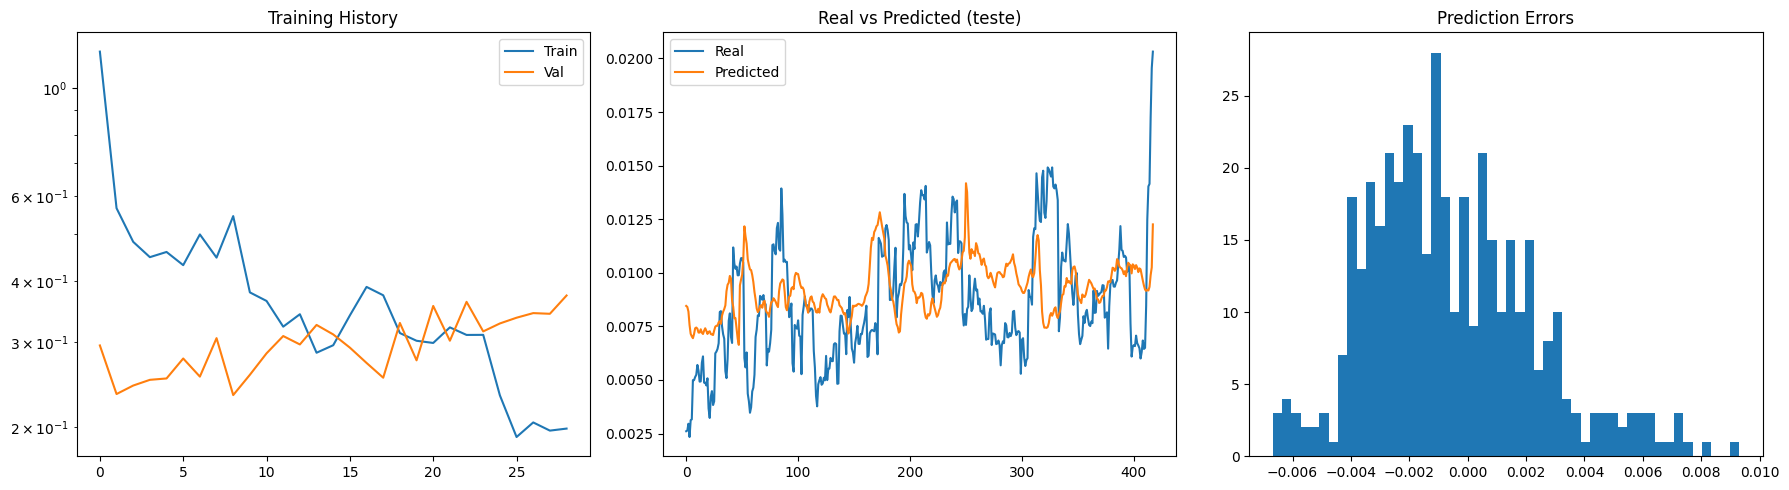

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history["loss"], label="Train")
axes[0].plot(history.history["val_loss"], label="Val")
axes[0].set_yscale("log")
axes[0].set_title("Training History")
axes[0].legend()

axes[1].plot(y_test, label="Real")
axes[1].plot(y_pred_test.flatten(), label="Predicted")
axes[1].set_title("Real vs Predicted (teste)")
axes[1].legend()

errors = y_test - y_pred_test.flatten()
axes[2].hist(errors, bins=50)
axes[2].set_title("Prediction Errors")

plt.tight_layout()
plt.show()

In [84]:
print("\n── Correlações com o target ──")
corr_df = pd.DataFrame(X.values, columns=X.columns)
corr_df["target"] = y.values[: len(corr_df)]
correlations = (
    corr_df.corr()["target"].drop("target").sort_values(key=abs, ascending=False)
)
print(correlations)


── Correlações com o target ──
hist_vol_10               0.766073
vix                       0.586819
garch_rank                0.462480
oil_market_balance_mbd    0.371420
gvz_zscore_60d            0.324389
eur_usd                   0.319434
real_rate_proxy          -0.303255
gvz_pct_change            0.241870
rsi_14                   -0.058273
silver_high              -0.024307
Name: target, dtype: float64
